# BANKRUPTCY PREVENTION PROJECT - FULL CODE
# DATASET DETAILS + EDA + MODEL BUILDING + MODEL EVALUATION

### 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

### 2. LOAD DATASET

In [47]:
df_raw = pd.read_excel(r"C:\Users\D.Anand\Desktop\bankruptcy-prevention.xlsx")

print("Original Data Preview:")
print(df_raw.head())

Original Data Preview:
  industrial_risk; management_risk; financial_flexibility;  credibility;  \
0                         0.5;1;0;0;0;0.5;bankruptcy                 NaN   
1                             0;1;0;0;0;1;bankruptcy                 NaN   
2                             1;0;0;0;0;1;bankruptcy                 NaN   
3                         0.5;0;0;0.5;0;1;bankruptcy                 NaN   
4                             1;1;0;0;0;1;bankruptcy                 NaN   

   competitiveness;  operating_risk;  class  
0               NaN              NaN    NaN  
1               NaN              NaN    NaN  
2               NaN              NaN    NaN  
3               NaN              NaN    NaN  
4               NaN              NaN    NaN  


### 3. FIX DATA FORMAT

In [48]:
rows = []

for _, row in df_raw.iterrows():
    values = [str(x).strip() for x in row.tolist() if pd.notna(x)]
    joined_row = " ".join(values)
    joined_row = joined_row.replace(" ;", ";").replace("; ", ";")
    split_row = joined_row.split(";")

    if len(split_row) == 7:
        rows.append(split_row)

df = pd.DataFrame(rows, columns=[
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk",
    "class"
])

print("\nCleaned Data Preview:")
print(df.head())


Cleaned Data Preview:
  industrial_risk management_risk financial_flexibility credibility  \
0             0.5               1                     0           0   
1               0               1                     0           0   
2               1               0                     0           0   
3             0.5               0                     0         0.5   
4               1               1                     0           0   

  competitiveness operating_risk       class  
0               0            0.5  bankruptcy  
1               0              1  bankruptcy  
2               0              1  bankruptcy  
3               0              1  bankruptcy  
4               0              1  bankruptcy  


### 4. DATASET DETAILS

In [49]:
print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types Before Conversion:")
print(df.dtypes)

print("\nMissing Values Before Conversion:")
print(df.isnull().sum())


Shape of Dataset:
(250, 7)

Column Names:
Index(['industrial_risk', 'management_risk', 'financial_flexibility',
       'credibility', 'competitiveness', 'operating_risk', 'class'],
      dtype='object')

Data Types Before Conversion:
industrial_risk          object
management_risk          object
financial_flexibility    object
credibility              object
competitiveness          object
operating_risk           object
class                    object
dtype: object

Missing Values Before Conversion:
industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64


### 5. CONVERT NUMERIC COLUMNS

In [50]:
numeric_columns = [
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nData Types After Conversion:")
print(df.dtypes)


Data Types After Conversion:
industrial_risk          float64
management_risk          float64
financial_flexibility    float64
credibility              float64
competitiveness          float64
operating_risk           float64
class                     object
dtype: object


### 6. HANDLE MISSING VALUES

In [51]:
for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

df["class"].fillna(df["class"].mode()[0], inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64


### 7. SUMMARY STATISTICS

In [52]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       industrial_risk  management_risk  financial_flexibility  credibility  \
count       250.000000       250.000000             250.000000   250.000000   
mean          0.518000         0.614000               0.376000     0.470000   
std           0.411526         0.410705               0.401583     0.415682   
min           0.000000         0.000000               0.000000     0.000000   
25%           0.000000         0.500000               0.000000     0.000000   
50%           0.500000         0.500000               0.500000     0.500000   
75%           1.000000         1.000000               0.500000     1.000000   
max           1.000000         1.000000               1.000000     1.000000   

       competitiveness  operating_risk  
count       250.000000      250.000000  
mean          0.476000        0.570000  
std           0.440682        0.434575  
min           0.000000        0.000000  
25%           0.000000        0.000000  
50%           0.50000

### 8. TARGET CLASS DISTRIBUTION

In [53]:
print("\nTarget Class Distribution:")
print(df["class"].value_counts())


Target Class Distribution:
class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64


### 9. EDA - TARGET COUNT PLOT

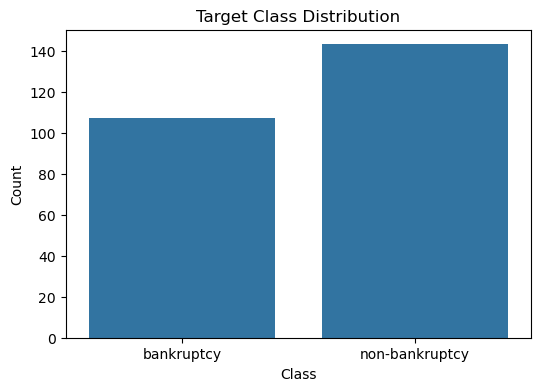

In [54]:
plt.figure(figsize=(6, 4))
sns.countplot(x="class", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### 10. EDA - HISTOGRAMS

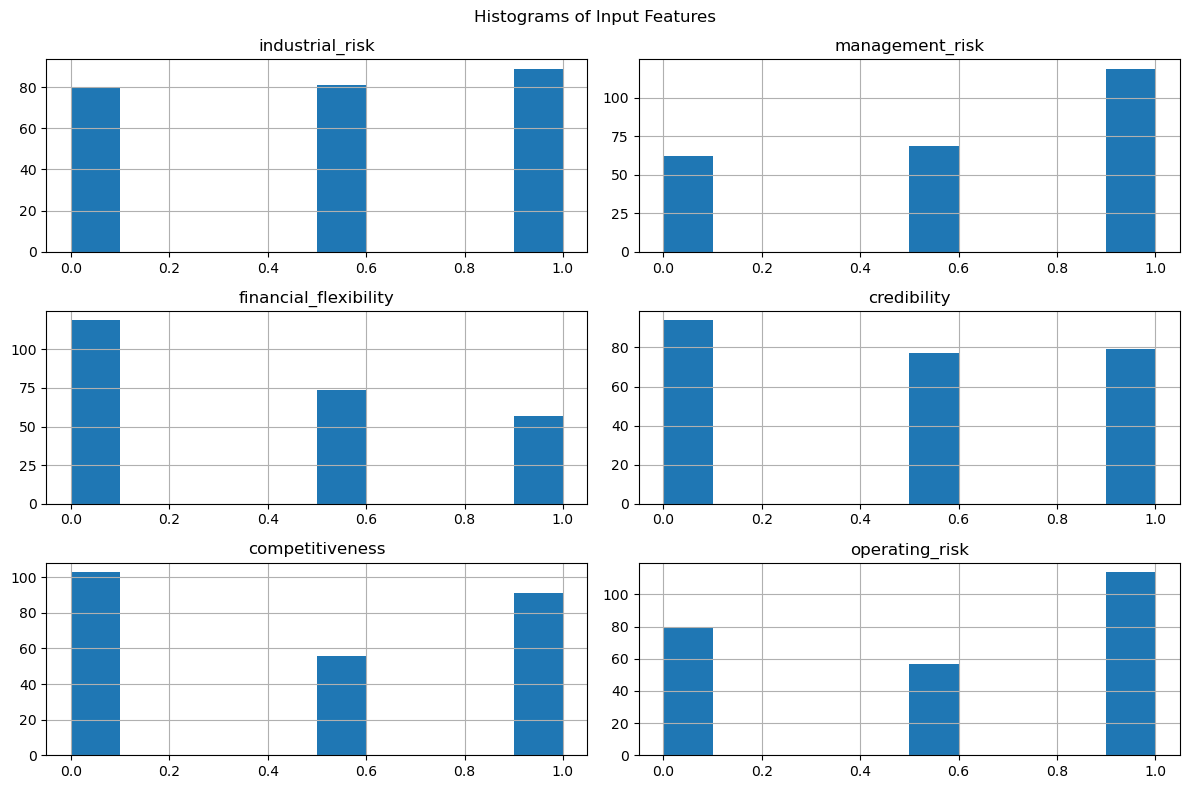

In [55]:
df[numeric_columns].hist(figsize=(12, 8), bins=10)
plt.suptitle("Histograms of Input Features")
plt.tight_layout()
plt.show()

### 11. EDA - BOXPLOTS

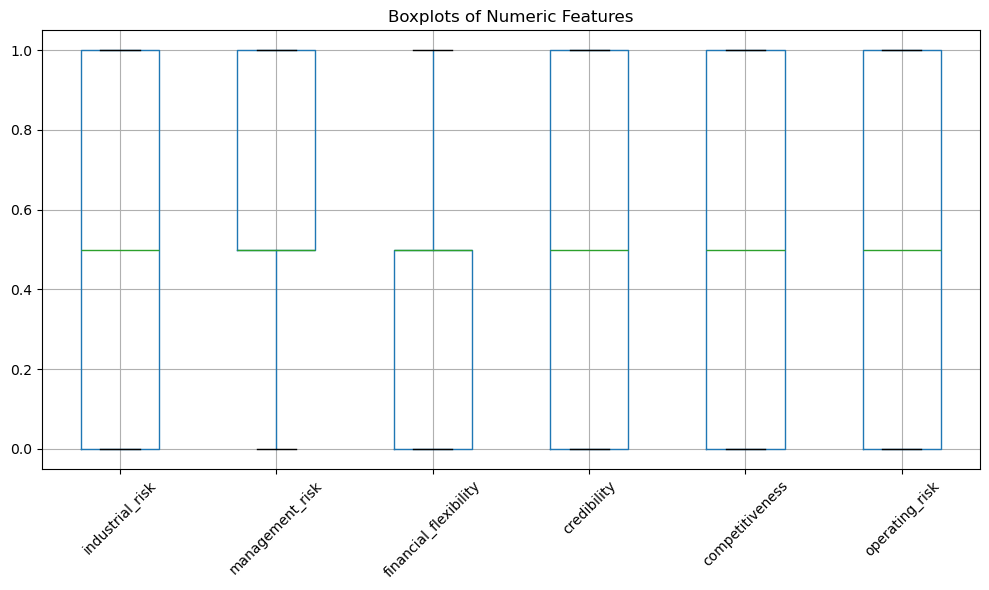

In [56]:
plt.figure(figsize=(10, 6))
df[numeric_columns].boxplot()
plt.title("Boxplots of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 12. EDA - CORRELATION MATRIX

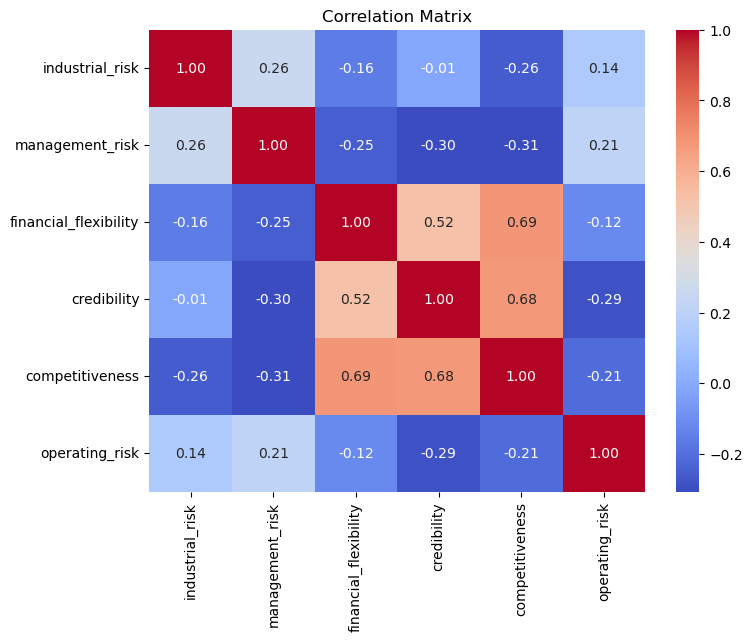

In [57]:
plt.figure(figsize=(8, 6))
corr_matrix = df[numeric_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### 13. EDA - PAIRPLOT

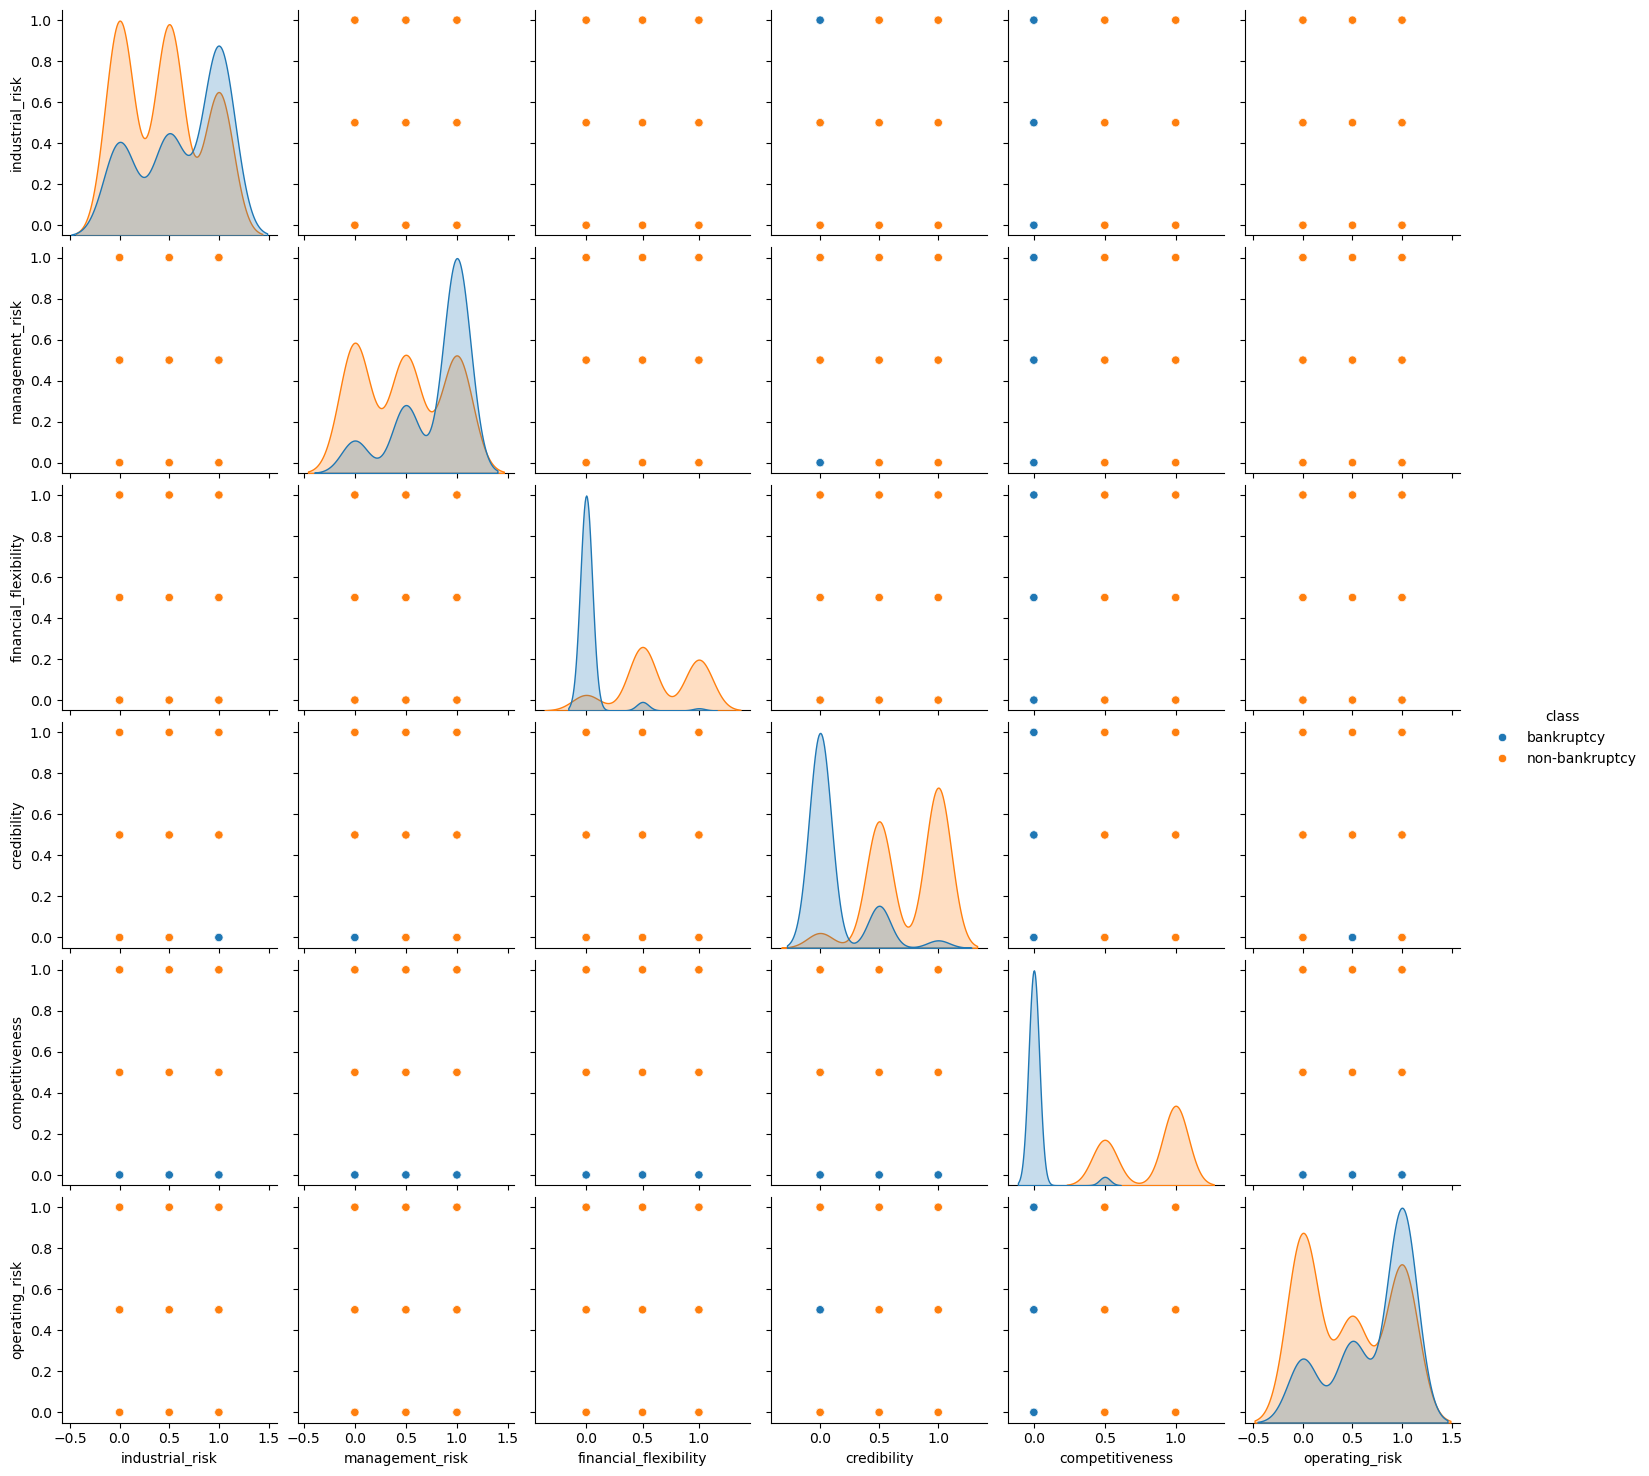

In [58]:
sns.pairplot(df, vars=numeric_columns, hue="class")
plt.show()

### 14. ENCODE TARGET COLUMN

In [59]:
label_encoder = LabelEncoder()
df["class_encoded"] = label_encoder.fit_transform(df["class"])

print("\nEncoded Target Preview:")
print(df[["class", "class_encoded"]].head())


Encoded Target Preview:
        class  class_encoded
0  bankruptcy              0
1  bankruptcy              0
2  bankruptcy              0
3  bankruptcy              0
4  bankruptcy              0


### 15. DEFINE FEATURES AND TARGET

In [60]:
X = df[numeric_columns]
y = df["class_encoded"]

print("\nFeature Data:")
print(X.head())

print("\nTarget Data:")
print(y.head())


Feature Data:
   industrial_risk  management_risk  financial_flexibility  credibility  \
0              0.5              1.0                    0.0          0.0   
1              0.0              1.0                    0.0          0.0   
2              1.0              0.0                    0.0          0.0   
3              0.5              0.0                    0.0          0.5   
4              1.0              1.0                    0.0          0.0   

   competitiveness  operating_risk  
0              0.0             0.5  
1              0.0             1.0  
2              0.0             1.0  
3              0.0             1.0  
4              0.0             1.0  

Target Data:
0    0
1    0
2    0
3    0
4    0
Name: class_encoded, dtype: int64


### 16. TRAIN-TEST SPLIT

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (200, 6)
Testing Shape: (50, 6)


### 17. DEFINE MODELS

In [62]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression())
    ]),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),
    
    "Naive Bayes": GaussianNB()
}

### 18. TRAIN, PREDICT, EVALUATE


================ Logistic Regression ================

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



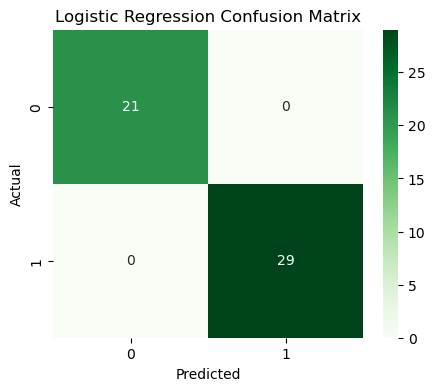


================ Decision Tree ================

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



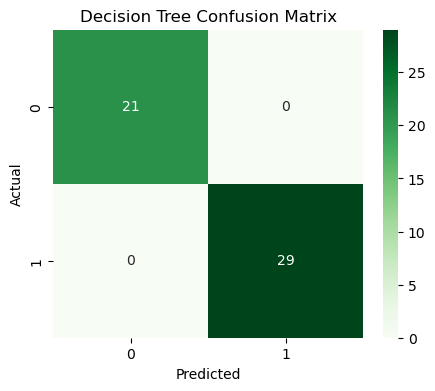


================ Random Forest ================

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



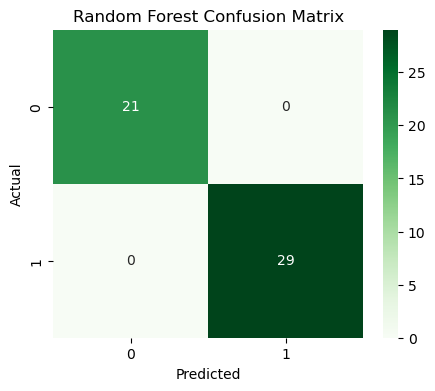


================ KNN ================

Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        21
           1       1.00      0.93      0.96        29

    accuracy                           0.96        50
   macro avg       0.96      0.97      0.96        50
weighted avg       0.96      0.96      0.96        50



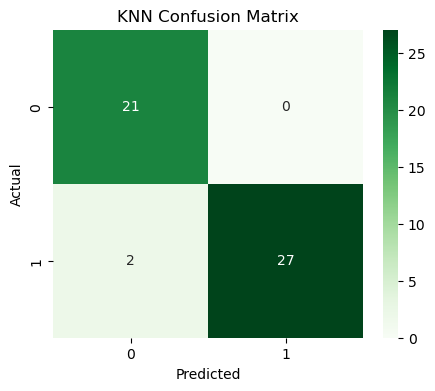


================ SVM ================

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



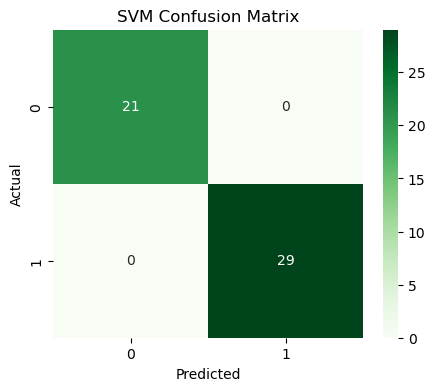


================ Naive Bayes ================

Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.97      1.00      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



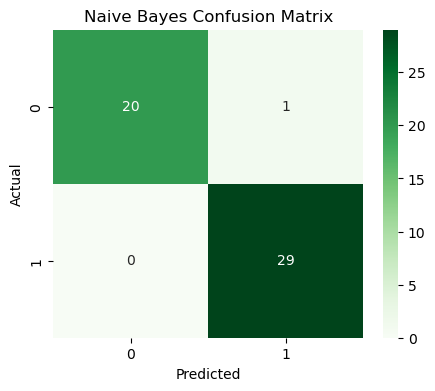

In [63]:
results = []

for model_name, model in models.items():
    print(f"\n================ {model_name} ================\n")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Probability-based ROC AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    
    results.append({
        "Model": model_name,
        "Test Accuracy": accuracy,
        "CV Mean Accuracy": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "ROC-AUC": roc_auc
    })

### 19. RESULTS TABLE

In [64]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="CV Mean Accuracy", ascending=False)

print("\nFinal Model Comparison:")
print(results_df)


Final Model Comparison:
                 Model  Test Accuracy  CV Mean Accuracy    CV Std  ROC-AUC
0  Logistic Regression           1.00             0.996  0.008000      1.0
2        Random Forest           1.00             0.996  0.008000      1.0
4                  SVM           1.00             0.996  0.008000      1.0
1        Decision Tree           1.00             0.992  0.016000      1.0
3                  KNN           0.96             0.992  0.016000      1.0
5          Naive Bayes           0.98             0.972  0.009798      1.0


### 20. VISUALIZE RESULTS

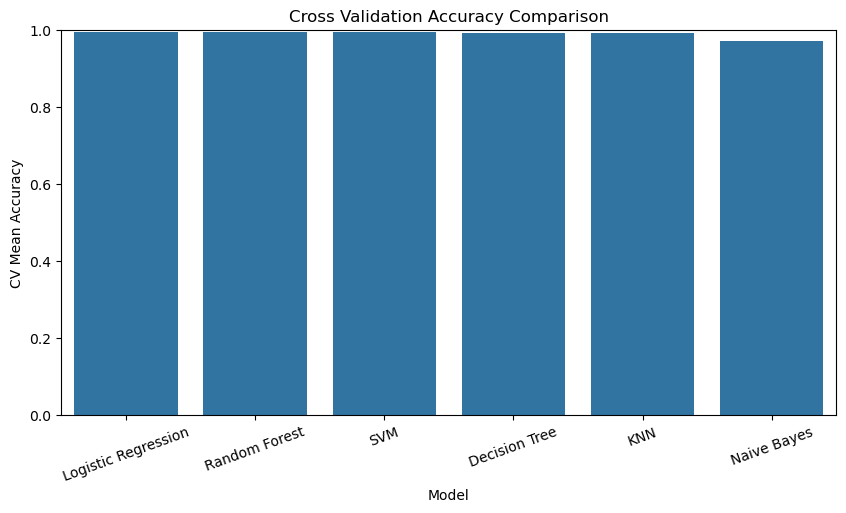

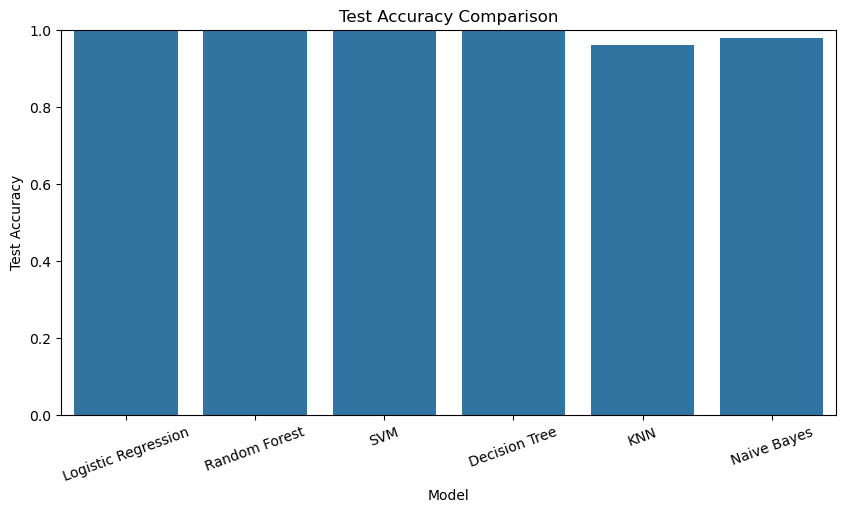

In [65]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="CV Mean Accuracy")
plt.title("Cross Validation Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

### 21. FEATURE IMPORTANCE


Random Forest Feature Importance:
competitiveness          0.522158
financial_flexibility    0.223062
credibility              0.187083
management_risk          0.029129
operating_risk           0.020926
industrial_risk          0.017642
dtype: float64


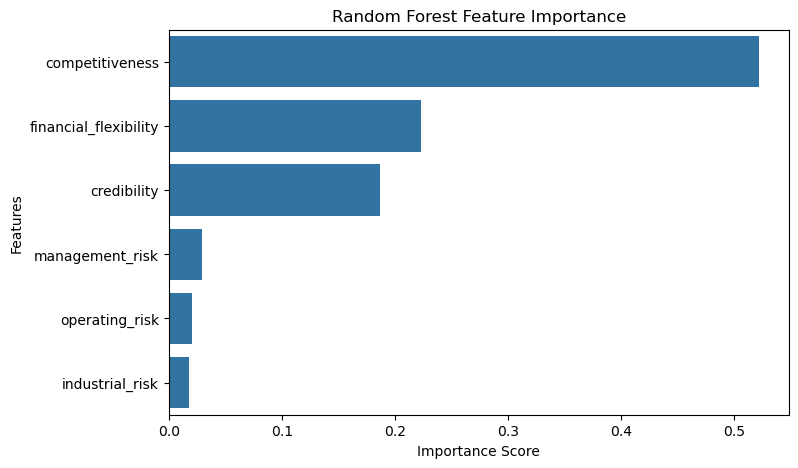

In [66]:
# Feature importance is available from Random Forest
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nRandom Forest Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### 22. BEST MODEL

In [67]:
best_model_name = results_df.iloc[0]["Model"]
print("\nBest Model Based On Cross Validation Accuracy:", best_model_name)


Best Model Based On Cross Validation Accuracy: Logistic Regression


### 23. FINAL MESSAGE

In [68]:
print("\nProject Completed Successfully:")
print("1. Dataset Details")
print("2. EDA")
print("3. Model Building")
print("4. Model Evaluation")
print("5. Model Comparison")
print("6. Feature Importance")


Project Completed Successfully:
1. Dataset Details
2. EDA
3. Model Building
4. Model Evaluation
5. Model Comparison
6. Feature Importance


## 24. Streamlit app.py Code 

In [74]:
streamlit_code = r'''

import os
import joblib
import pandas as pd
import streamlit as st

st.set_page_config(
    page_title="Bankruptcy Prediction System",
    page_icon="📊",
    layout="wide"
)

MODEL_PATH = r"C:\Users\D.Anand\Desktop\bankruptcy\bankruptcy_model.pkl"

# -----------------------------
# CUSTOM STYLE
# -----------------------------
st.markdown("""
    <style>
    .main-title {
        font-size: 40px;
        font-weight: 700;
        margin-bottom: 0.2rem;
    }
    .sub-text {
        font-size: 18px;
        color: #b0b0b0;
        margin-bottom: 1rem;
    }
    .status-ok {
        color: #22c55e;
        font-weight: 600;
    }
    .status-bad {
        color: #ef4444;
        font-weight: 600;
    }
    </style>
""", unsafe_allow_html=True)

# -----------------------------
# LOAD MODEL
# -----------------------------
@st.cache_resource
def load_model():
    try:
        if not os.path.exists(MODEL_PATH):
            return None, f"Model file not found: {MODEL_PATH}"
        model = joblib.load(MODEL_PATH)
        return model, None
    except Exception as e:
        return None, str(e)

model, load_error = load_model()

# -----------------------------
# SESSION STATE
# -----------------------------
if "prediction_history" not in st.session_state:
    st.session_state.prediction_history = []

# -----------------------------
# HEADER
# -----------------------------
st.markdown('<div class="main-title">📊 Bankruptcy Prediction System</div>', unsafe_allow_html=True)
st.markdown(
    '<div class="sub-text">Predict whether a company is likely to face Bankruptcy or Non-Bankruptcy based on risk indicators.</div>',
    unsafe_allow_html=True
)

col_status1, col_status2 = st.columns([2, 3])

with col_status1:
    if model is not None:
        st.markdown('<p class="status-ok">✅ Model Status: Loaded Successfully</p>', unsafe_allow_html=True)
    else:
        st.markdown('<p class="status-bad">❌ Model Status: Not Loaded</p>', unsafe_allow_html=True)
        st.error(f"Error loading model: {load_error}")

with col_status2:
    st.info("Risk Level Guide: 0 = Low, 0.5 = Medium, 1 = High")

# -----------------------------
# SIDEBAR INPUTS
# -----------------------------
st.sidebar.header("Enter Risk Details")

industrial_risk = st.sidebar.selectbox("Industrial Risk", [0, 0.5, 1], index=0)
management_risk = st.sidebar.selectbox("Management Risk", [0, 0.5, 1], index=0)
financial_flexibility = st.sidebar.selectbox("Financial Flexibility", [0, 0.5, 1], index=0)
credibility = st.sidebar.selectbox("Credibility", [0, 0.5, 1], index=0)
competitiveness = st.sidebar.selectbox("Competitiveness", [0, 0.5, 1], index=0)
operating_risk = st.sidebar.selectbox("Operating Risk", [0, 0.5, 1], index=0)

st.sidebar.markdown("---")
predict_btn = st.sidebar.button("🔍 Predict")
clear_btn = st.sidebar.button("🗑️ Clear History")

if clear_btn:
    st.session_state.prediction_history = []
    st.sidebar.success("Prediction history cleared.")

# -----------------------------
# INPUT DATAFRAME
# -----------------------------
input_df = pd.DataFrame({
    "industrial_risk": [industrial_risk],
    "management_risk": [management_risk],
    "financial_flexibility": [financial_flexibility],
    "credibility": [credibility],
    "competitiveness": [competitiveness],
    "operating_risk": [operating_risk]
})

# -----------------------------
# MAIN LAYOUT
# -----------------------------
left_col, right_col = st.columns([1.1, 1])

with left_col:
    st.subheader("Selected Input Features")
    st.dataframe(input_df, use_container_width=True)

    st.markdown("### Sample CSV Download")
    sample_csv = input_df.to_csv(index=False).encode("utf-8")
    st.download_button(
        label="⬇️ Download Current Input as CSV",
        data=sample_csv,
        file_name="bankruptcy_input_sample.csv",
        mime="text/csv"
    )

with right_col:
    st.subheader("Input Summary")
    st.metric("Industrial Risk", industrial_risk)
    st.metric("Management Risk", management_risk)
    st.metric("Financial Flexibility", financial_flexibility)
    st.metric("Credibility", credibility)
    st.metric("Competitiveness", competitiveness)
    st.metric("Operating Risk", operating_risk)

# -----------------------------
# PREDICTION SECTION
# -----------------------------
if predict_btn:
    st.markdown("---")
    st.subheader("Prediction Result")

    if model is None:
        st.warning("⚠️ Model not loaded. Please check the PKL file.")
    else:
        try:
            prediction = model.predict(input_df)[0]

            if hasattr(model, "predict_proba"):
                proba = model.predict_proba(input_df)[0]
                confidence = max(proba)
            else:
                confidence = None

            if prediction == 0:
                result_text = "Bankruptcy"
                st.error(f"🚨 Prediction: {result_text}")
            else:
                result_text = "Non-Bankruptcy"
                st.success(f"✅ Prediction: {result_text}")

            if confidence is not None:
                st.write(f"**Confidence Score:** {confidence:.2%}")
                st.progress(float(confidence))

            # Save history
            history_row = input_df.copy()
            history_row["Prediction"] = result_text
            history_row["Confidence"] = f"{confidence:.2%}" if confidence is not None else "N/A"

            st.session_state.prediction_history.append(history_row)

        except Exception as e:
            st.error(f"Prediction error: {e}")

# -----------------------------
# HISTORY SECTION
# -----------------------------
if st.session_state.prediction_history:
    st.markdown("---")
    st.subheader("Prediction History")

    history_df = pd.concat(st.session_state.prediction_history, ignore_index=True)
    st.dataframe(history_df, use_container_width=True)

    history_csv = history_df.to_csv(index=False).encode("utf-8")
    st.download_button(
        label="⬇️ Download Prediction History",
        data=history_csv,
        file_name="prediction_history.csv",
        mime="text/csv"
    )

# -----------------------------
# FOOTER
# -----------------------------
st.markdown("---")
with st.expander("⚙️ Run Commands"):
    st.code("pip install streamlit scikit-learn pandas joblib")
    st.code("python -m streamlit run app.py")

with st.expander("ℹ️ About This App"):
    st.write("""
    This application predicts whether a company is likely to face **Bankruptcy** or **Non-Bankruptcy**
    using a machine learning model trained on risk-related business features:
    
    - Industrial Risk
    - Management Risk
    - Financial Flexibility
    - Credibility
    - Competitiveness
    - Operating Risk
    """)
'''
print(streamlit_code)



import os
import joblib
import pandas as pd
import streamlit as st

st.set_page_config(
    page_title="Bankruptcy Prediction System",
    page_icon="📊",
    layout="wide"
)

MODEL_PATH = r"C:\Users\D.Anand\Desktop\bankruptcy\bankruptcy_model.pkl"

# -----------------------------
# CUSTOM STYLE
# -----------------------------
st.markdown("""
    <style>
    .main-title {
        font-size: 40px;
        font-weight: 700;
        margin-bottom: 0.2rem;
    }
    .sub-text {
        font-size: 18px;
        color: #b0b0b0;
        margin-bottom: 1rem;
    }
    .status-ok {
        color: #22c55e;
        font-weight: 600;
    }
    .status-bad {
        color: #ef4444;
        font-weight: 600;
    }
    </style>
""", unsafe_allow_html=True)

# -----------------------------
# LOAD MODEL
# -----------------------------
@st.cache_resource
def load_model():
    try:
        if not os.path.exists(MODEL_PATH):
            return None, f"Model file not found: {MODEL_PATH}"
        model = j